Libraries imported successfully!
Dataset loaded successfully!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


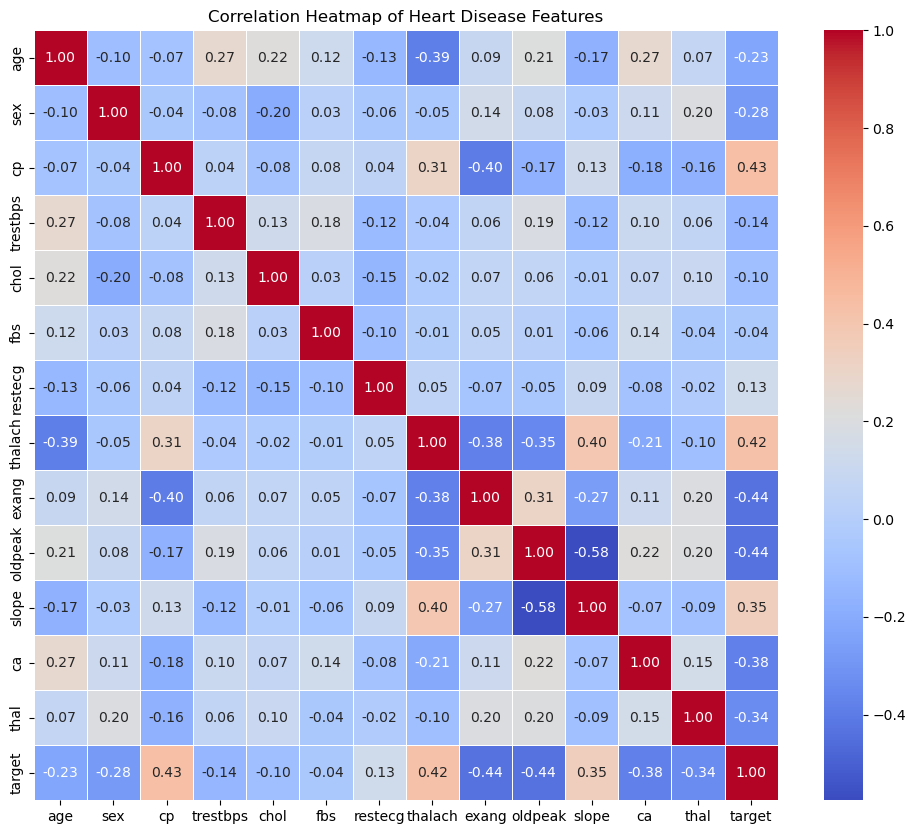

In [1]:
# 1. Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier

print("Libraries imported successfully!")
# 2. Loading the dataset
# Load the cleaned dataset
df = pd.read_csv('cleaned_heart_data.csv')
print("Dataset loaded successfully!")

display(df.head())

# 3. Feature Engineering: Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Heart Disease Features')
plt.show()

In [2]:
# 4. Feature Selection and Data Splitting
# Separating the features (X) and the target variable (y)
X = df.drop('target', axis=1)
y = df['target']

# Splitting the dataset into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
# KNN is a distance-based algorithm, so scaling the features is mandatory
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

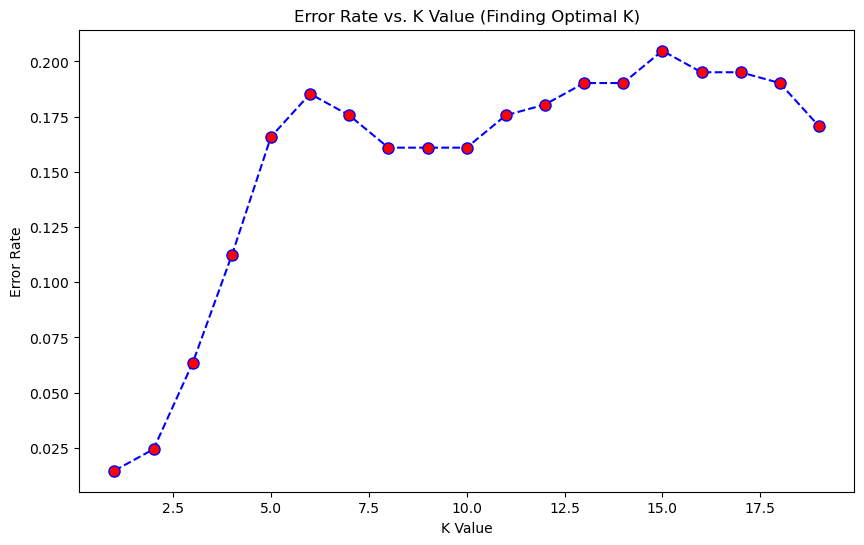

In [3]:
# 6. KNN Model Implementation
# Initializing and training the K-Nearest Neighbors Classifier (using k=5)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# 7. Model Evaluation, Optimal K Analysis & Confusion Matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# A. Finding the optimal K value (Error Rate vs K)
error_rate = []
for i in range(1, 20):
    knn_temp = KNeighborsClassifier(n_neighbors=i)
    knn_temp.fit(X_train_scaled, y_train)
    pred_i = knn_temp.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

# Plotting Error Rate vs K
plt.figure(figsize=(10,6))
plt.plot(range(1, 20), error_rate, color='blue', linestyle='dashed', marker='o', markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value (Finding Optimal K)')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.show()

--- Final KNN Model Evaluation Results ---
Accuracy Score: 0.8341

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82       102
           1       0.80      0.89      0.84       103

    accuracy                           0.83       205
   macro avg       0.84      0.83      0.83       205
weighted avg       0.84      0.83      0.83       205



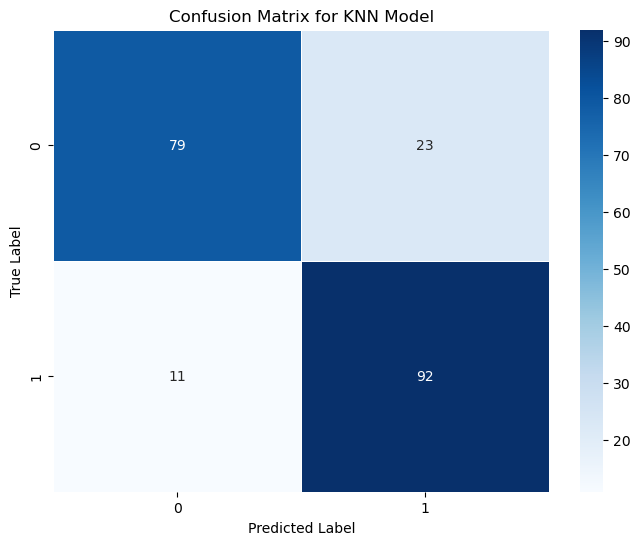

In [4]:
# B. Final Model Prediction (Using k=5)
y_pred = knn_model.predict(X_test_scaled)

print("--- Final KNN Model Evaluation Results ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# C. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix for KNN Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()